# Flood · Wind-farm — M2 coupling: per-node flood depth, all three sub-perils (riverine + pluvial + coastal)

**Magnitude metric:** inundation **depth (ft above ground)** sampled at each turbine and the collector substation —
riverine/pluvial indexed by annual return period (10–500-yr), coastal surge by hurricane category (per storm).
**Data source:** the shared M1 flood-field/catalog manifests filtered to this asset — FEMA BLE/SFHA riverine water
surface, NOAA Atlas 14 → SCS-CN pluvial runoff over 1 m lidar (USGS 3DEP via TNM) pad ponding, and the NOAA SLOSH MOM
surge raster; USGS EPQS ground elevations + USWTDB turbine geometry (Amazon Wind US East = 104 turbines + collector).
**What this notebook does:** one notebook samples the M1 fields at every node and pad-gates them
([JD-FL-17](../../../../docs/plans/flood/decisions.md), [JD-FL-19](../../../../docs/plans/flood/decisions.md)):
- **Riverine** — sample the 1% water surface at each node, `depth = WSE + ΔWSE(T) − ground − pad`, gated to the SFHA;
  `Q(T)` read per site from its own gauge record.
- **Pluvial** — pour the M1 runoff over each pad's 1 m-lidar closed-depression `f`/`d_cap`, pad-gated (raised pads
  shed shallow ponding).
- **Coastal** — sample the SLOSH MOM field at each node per hurricane category → per-storm surge (event-based,
  `event_family_id`-stamped); SLOSH LZW tiles are GDAL-decompressed to DEFLATE (cached) so this runs in the standard
  hazard env without `imagecodecs`. Only coastal-exposed wind sites qualify.

Riverine/pluvial are return-period (annual-max frame); coastal is event-based. Output is the per-node depth tables +
coupling manifest M3 reads to apply the source-agnostic depth→damage curve.

In [1]:
import json, os, subprocess, sys
from pathlib import Path
import numpy as np, pandas as pd, requests, tifffile, pyproj
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from shapely import wkt
from shapely.geometry import Point
from shapely.ops import transform
from skimage.morphology import reconstruction

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "AGENTS.md").exists():
    ROOT = ROOT.parent
RAW = ROOT / "data" / "flood" / "raw"; OUT = ROOT / "data" / "flood"
EPQS = "https://epqs.nationalmap.gov/v1/json"
PAD = {"turbine": 0.30, "substation": 0.15}; RATING_EXP = 0.6
RPS_RIV = [10, 25, 50, 100, 250, 500]
SESS = requests.Session()
SESS.mount("https://", HTTPAdapter(max_retries=Retry(total=5, backoff_factor=0.8, status_forcelist=[429, 500, 502, 503, 504])))
SESS.headers.update({"User-Agent": "infrasure-hazard-modeling/0.1 (flood wind M2)"})
def epqs(lat, lon):
    try:
        return float(SESS.get(EPQS, params={"x": lon, "y": lat, "units": "Meters", "wkid": 4326}, timeout=20).json()["value"])
    except Exception:
        return None
def wse_at(lon, lat, bxy, bz, k=6):
    d2 = (bxy[:, 0] - lon) ** 2 + (bxy[:, 1] - lat) ** 2
    return float(np.median(bz[np.argsort(d2)[:k]]))

## 1 · Riverine — sample the 1% water surface at each node → per-node bathtub depth (the coupling)

In [2]:
rman = json.loads((OUT / "flood_riverine_m1_catalog_manifest.json").read_text())     # shared riverine FIELD manifest (all sites, method-tagged)
riv_nodes = {}   # slug -> per-node depth table  (Q(T) is read PER SITE from fm["gauge"] inside the loop, JD-FL-19)
for fm in rman["field"]:
    if fm["asset"] != "wind_farm":            # this asset's sites only (wind = sfha_bathtub / dry; JD-FL-19)
        continue
    s_slug = fm["slug"]
    tb = pd.read_parquet(OUT / f"{s_slug}_flood_wind_m0_geometry.parquet")
    nodes = tb[["lon", "lat"]].copy(); nodes["kind"] = "turbine"; nodes["pad_m"] = PAD["turbine"]
    # substation node (from M0 sites)
    s0 = next(x for x in json.loads((OUT / "flood_wind_m0_sites.json").read_text())["sites"] if x["slug"] == s_slug)
    nodes.loc[len(nodes)] = [s0["sub_lon"], s0["sub_lat"], "substation", PAD["substation"]]
    if fm["flood_area_path"] is None:                      # dry baseline
        for rp in RPS_RIV: nodes[f"depth_{rp}_m"] = 0.0
        riv_nodes[s_slug] = nodes
        nodes.to_parquet(OUT / f"{s_slug}_flood_wind_riverine_m2_depths.parquet", index=False)
        continue
    QT = {int(k): v for k, v in fm["gauge"]["Q_cfs"].items()}   # this site's OWN gauge Q(T) (per-site, JD-FL-19)
    area = wkt.loads((ROOT / fm["flood_area_path"]).read_text())   # de-inlined polygon from gitignored raw/ (#5)
    bxy = np.array(fm["wse_contour"]["xy"]); bz = np.array(fm["wse_contour"]["z"])
    gcache = RAW / f"ground_{s_slug}.json"
    nodes["ground_m"] = json.loads(gcache.read_text()) if gcache.exists() else [epqs(r.lat, r.lon) for r in nodes.itertuples()]
    if not gcache.exists(): gcache.write_text(json.dumps(nodes["ground_m"].tolist()))
    nodes["wse100_m"] = [wse_at(r.lon, r.lat, bxy, bz) if np.isfinite(r.ground_m) else np.nan for r in nodes.itertuples()]
    nodes["in_sfha"] = [area.contains(Point(r.lon, r.lat)) for r in nodes.itertuples()]
    d100_in = (nodes["wse100_m"] - nodes["ground_m"] - nodes["pad_m"]).where(nodes["in_sfha"]).clip(lower=0)
    d_char = float(np.nanmax(d100_in)) if np.isfinite(np.nanmax(d100_in)) else 1.0
    dwse = {rp: d_char * ((QT[rp] / QT[100]) ** RATING_EXP - 1) for rp in RPS_RIV}     # ΔWSE(T), 0 at 100-yr
    for rp in RPS_RIV:
        depth = (nodes["wse100_m"] + dwse[rp] - nodes["ground_m"] - nodes["pad_m"]).clip(lower=0)
        depth = depth.where(np.isfinite(nodes["ground_m"]), 0.0).fillna(0.0)
        nodes[f"depth_{rp}_m"] = np.round(depth.values, 3)
    riv_nodes[s_slug] = nodes
    nodes.to_parquet(OUT / f"{s_slug}_flood_wind_riverine_m2_depths.parquet", index=False)
    print(f"  {fm['name']:16s} 100-yr: {int((nodes[nodes.kind=='turbine']['depth_100_m']>0).sum())} turbines wet, "
          f"substation {nodes[nodes.kind=='substation']['depth_100_m'].iloc[0]:.2f} m")

  Green River      100-yr: 22 turbines wet, substation 0.89 m
  Amazon Wind Farm US East 100-yr: 13 turbines wet, substation 0.00 m


## 2 · Pluvial — per-node 1 m-lidar `f`/`d_cap` + pad-gated ponding from the M1 runoff field (the coupling)

Each pad's own 1 m-lidar window → closed-depression `f`/`d_cap`; ponding `= min(r·Q/f, d_cap)`; node equipment depth
`= max(pond − pad, 0)`. The raised pads shed the shallow ponding (JD-FL-W6 — pluvial negligible for wind). Lidar cached.

In [3]:
sites = json.loads((OUT / "flood_wind_m0_sites.json").read_text())["sites"]
GDALBIN = Path(sys.executable).parent
_GENV = dict(os.environ, GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR")
_LCACHE = OUT / "raw" / "lidar"; _LCACHE.mkdir(parents=True, exist_ok=True)
FALLBACK_F, FALLBACK_DCAP_M, POND_THRESH_M, WINDOW_M = 0.10, 0.50, 0.05, 240

def _utm_epsg(lon): return 26900 + int((lon + 180) / 6) + 1
def _tnm_1m_tiles(bounds):
    mnx, mny, mxx, mxy = bounds
    r = requests.get("https://tnmaccess.nationalmap.gov/api/v1/products",
                     params={"datasets": "Digital Elevation Model (DEM) 1 meter", "bbox": f"{mnx},{mny},{mxx},{mxy}",
                             "outputFormat": "JSON", "max": 50}, timeout=60)
    return [it["downloadURL"] for it in r.json().get("items", [])]
def _site_vrt(slug, node_bounds):
    vrt = _LCACHE / f"{slug}.vrt"
    if vrt.exists(): return vrt
    pad = 0.01; mnx, mny, mxx, mxy = node_bounds
    tiles = _tnm_1m_tiles((mnx - pad, mny - pad, mxx + pad, mxy + pad))
    if not tiles: return None
    lst = _LCACHE / f"{slug}_tiles.txt"; lst.write_text("\n".join("/vsicurl/" + u for u in tiles))
    subprocess.run([str(GDALBIN / "gdalbuildvrt"), "-q", "-input_file_list", str(lst), str(vrt)], env=_GENV, check=True, capture_output=True)
    return vrt
def _closed_depression(dem_a, thr=POND_THRESH_M):
    valid = (dem_a > -9990) & np.isfinite(dem_a)
    if valid.sum() < 100: return None
    work = dem_a.copy(); work[~valid] = dem_a[valid].min() - 100.0
    mk = np.full_like(work, work.max())
    mk[0, :] = work[0, :]; mk[-1, :] = work[-1, :]; mk[:, 0] = work[:, 0]; mk[:, -1] = work[:, -1]
    depth = reconstruction(mk, work, method="erosion") - work
    pond = depth[(depth > thr) & valid]
    f = len(pond) / valid.sum(); d_cap = float(pond.mean()) if len(pond) else 0.0
    return round(max(f, 0.005), 4), round(d_cap, 4)
def lidar_node_fdcap(slug, nodes, win_m=WINDOW_M):
    cache = _LCACHE / f"{slug}_node_fdcap.parquet"
    if cache.exists(): return pd.read_parquet(cache)
    nb = (nodes.lon.min(), nodes.lat.min(), nodes.lon.max(), nodes.lat.max())
    vrt = _site_vrt(slug, nb); tmp = _LCACHE / f"{slug}_node.tif"; recs = []
    for nd in nodes.itertuples():
        res = None
        if vrt is not None:
            epsg = _utm_epsg(nd.lon)
            pt = transform(pyproj.Transformer.from_crs("EPSG:4326", f"EPSG:{epsg}", always_xy=True).transform, Point(nd.lon, nd.lat))
            h = win_m / 2.0
            try:
                subprocess.run([str(GDALBIN / "gdalwarp"), "-q", "-overwrite", "-t_srs", f"EPSG:{epsg}",
                                "-te", str(pt.x-h), str(pt.y-h), str(pt.x+h), str(pt.y+h), "-tr", "1", "1", "-r", "bilinear",
                                "-dstnodata", "-9999", str(vrt), str(tmp)], env=_GENV, check=True, capture_output=True)
                res = _closed_depression(tifffile.imread(str(tmp)).astype("f8"))
            except Exception:
                res = None
        f, d_cap = (FALLBACK_F, FALLBACK_DCAP_M) if res is None else res
        recs.append({"lon": nd.lon, "lat": nd.lat, "kind": nd.kind, "f": f, "d_cap_m": d_cap})
    out = pd.DataFrame(recs); out.to_parquet(cache, index=False); return out

plu_man = json.loads((OUT / "flood_pluvial_m1_catalog_manifest.json").read_text())   # shared pluvial FIELD manifest (all sites)
plu_field = pd.DataFrame(plu_man["field"])
plu_field = plu_field[plu_field.asset == "wind_farm"]                              # this asset's sites only
RPS_PLU = plu_man["depth_source"]["return_periods_yr"]
RETENTION = 0.5; PAD = {"turbine": 0.30, "substation": 0.15}
plu_nodes = {}
for s in sites:
    tb = pd.read_parquet(OUT / f"{s['slug']}_flood_wind_m0_geometry.parquet")
    nodes = tb[["lon", "lat"]].copy(); nodes["kind"] = "turbine"; nodes["pad_m"] = PAD["turbine"]
    nodes.loc[len(nodes)] = [s["sub_lon"], s["sub_lat"], "substation", PAD["substation"]]
    sf = plu_field[plu_field.slug == s["slug"]].set_index("rp_years")
    if bool(sf["atlas14_covered"].iloc[0]):
        fd = lidar_node_fdcap(s["slug"], nodes)
        nodes["f"] = fd["f"].values; nodes["d_cap_m"] = fd["d_cap_m"].values
        for rp in RPS_PLU:
            pond = np.minimum(RETENTION * sf.loc[rp, "runoff_m"] / nodes["f"], nodes["d_cap_m"])
            nodes[f"depth_{rp}_m"] = np.round(np.clip(pond - nodes["pad_m"], 0, None), 3)
    else:
        for rp in RPS_PLU: nodes[f"depth_{rp}_m"] = 0.0
    plu_nodes[s["slug"]] = nodes
    nodes.to_parquet(OUT / f"{s['slug']}_flood_wind_pluvial_m2_depths.parquet", index=False)

## 3 · Coastal — per-node SLOSH MOM surge (event-based), for coastal-exposed wind sites

Same SLOSH source + per-category sampling as solar's coastal M2, but **per node** and **pad-gated**. Event-based (per
storm), `event_family_id`-stamped. The SLOSH LZW tiles are read via a GDAL-decompressed (DEFLATE) copy — cached — so
this runs in the hazard env without `imagecodecs`. Inland wind sites (no `m0_coastal`) are skipped.

In [4]:
FT_M = 0.3048
SLOSH = OUT / "raw" / "slosh" / "US_SLOSH_MOM_Inundation_v2"
_SLOSH_DEFL = OUT / "raw" / "slosh" / "deflate"; _SLOSH_DEFL.mkdir(parents=True, exist_ok=True)
COASTAL_DEPTH_SOURCE = "SLOSH_MOM_US_v2_HighTide"   # JD-FL-14 tag

def _slosh_tfw(c):
    v = [float(x) for x in (SLOSH / f"US_Category{c}_MOM_Inundation_HighTide.tfw").read_text().split()]
    return v[0], v[3], v[4], v[5]   # px, py, ox, oy

def _slosh_arr(c):
    """SLOSH MOM Cat-c as an array, readable in ANY env: GDAL decompresses the LZW tile to DEFLATE (cached), tifffile reads it."""
    src = SLOSH / f"US_Category{c}_MOM_Inundation_HighTide.tif"
    defl = _SLOSH_DEFL / f"cat{c}_deflate.tif"
    if not defl.exists():
        subprocess.run([str(GDALBIN / "gdal_translate"), "-q", "-co", "COMPRESS=DEFLATE", str(src), str(defl)],
                       env=_GENV, check=True, capture_output=True)
    return tifffile.imread(str(defl))

def _slosh_node_depths_ft(c, lons, lats):
    px, py, ox, oy = _slosh_tfw(c); arr = _slosh_arr(c); out = []
    for lon, lat in zip(lons, lats):
        col = int((lon - ox) / px); row = int((lat - oy) / py)
        out.append((0.0 if (v := int(arr[row, col])) in (0, 255) else v - 0.5)
                   if 0 <= row < arr.shape[0] and 0 <= col < arr.shape[1] else 0.0)
    del arr; return np.array(out)

cman = json.loads((OUT / "flood_coastal_m1_catalog_manifest.json").read_text())
coastal_sites = [c for c in cman["sites"] if c["asset"] == "wind_farm" and c["exposed"]]
coa_nodes, coa_rows, coa_ladder = {}, [], {}
for cs in coastal_sites:
    cslug = cs["slug"]; scat = pd.read_parquet(OUT / cs["catalog_parquet"])
    tb = pd.read_parquet(OUT / f"{cslug}_flood_wind_m0_geometry.parquet")
    n = tb[["lon", "lat"]].copy(); n["kind"] = "turbine"; n["pad_m"] = PAD["turbine"]
    s0 = next(x for x in json.loads((OUT / "flood_wind_m0_sites.json").read_text())["sites"] if x["slug"] == cslug)
    n.loc[len(n)] = [s0["sub_lon"], s0["sub_lat"], "substation", PAD["substation"]]
    for c in range(1, 6):
        d_ft = _slosh_node_depths_ft(c, n["lon"].values, n["lat"].values)
        n[f"depth_cat{c}_m"] = np.round(np.clip(d_ft * FT_M - n["pad_m"].values, 0, None), 3)
    n.to_parquet(OUT / f"{cslug}_flood_wind_coastal_m2_node_depths.parquet", index=False)
    coa_nodes[cslug] = n
    coa_ladder[cslug] = {c: int((n[f"depth_cat{c}_m"] > 0).sum()) for c in range(1, 6)}
    t = n[n.kind == "turbine"]; sub = n[n.kind == "substation"].iloc[0]
    for r in scat.itertuples():
        cc = int(r.category); col = f"depth_cat{cc}_m" if 1 <= cc <= 5 else None
        td = t[col] if col else pd.Series([0.0] * len(t)); sd = float(sub[col]) if col else 0.0
        wet = td[td > 0]
        coa_rows.append({"sub_peril": "coastal", "slug": cslug, "name": cs["name"], "role": cs["role"],
                         "storm_ID": int(r.storm_ID), "event_family_id": int(r.event_family_id), "category": cc,
                         "n_turb": len(t), "n_flooded": int(len(wet)), "flooded_fraction": round(len(wet) / len(t), 4),
                         "turb_depth_mean_m": round(float(wet.mean()) if len(wet) else 0.0, 3),
                         "substation_depth_m": round(sd, 3), "depth_source": COASTAL_DEPTH_SOURCE})
coa = pd.DataFrame(coa_rows)
if len(coa):
    for cslug, g in coa.groupby("slug"):
        g.sort_values("event_family_id").to_parquet(OUT / f"{cslug}_flood_wind_coastal_m2_coupling.parquet", index=False)
    print("coastal per-category node-flood ladder (event-based):")
    print(coa.drop_duplicates(["name", "category"]).sort_values(["name", "category"])[
        ["name", "category", "n_flooded", "flooded_fraction", "turb_depth_mean_m", "substation_depth_m"]].to_string(index=False))
else:
    print("no coastal-exposed wind sites")

coastal per-category node-flood ladder (event-based):
                    name  category  n_flooded  flooded_fraction  turb_depth_mean_m  substation_depth_m
Amazon Wind Farm US East         1          0            0.0000              0.000               0.000
Amazon Wind Farm US East         2          0            0.0000              0.000               0.000
Amazon Wind Farm US East         3         64            0.6154              0.419               0.307


## 4 · Summarise the RP sub-perils (riverine + pluvial) + plot + checks + persist

Riverine/pluvial are RP-indexed (annual-max frame); coastal is event-based (per storm) → kept in its own per-storm
parquet above. M3 reads all three and applies the source-agnostic depth→damage node-by-node.

In [5]:
RPS = {"riverine": RPS_RIV, "pluvial": RPS_PLU}
def node_table(sp, slug):
    return riv_nodes[slug] if sp == "riverine" else plu_nodes[slug]

coup_rows = []
for sp in ("riverine", "pluvial"):
    for s in sites:
        nodes = node_table(sp, s["slug"])
        t = nodes[nodes.kind == "turbine"]; sub = nodes[nodes.kind == "substation"].iloc[0]
        for rp in RPS[sp]:
            wet = t[t[f"depth_{rp}_m"] > 0]
            coup_rows.append({"sub_peril": sp, "slug": s["slug"], "name": s["name"], "role": s["role"],
                              "rp_years": rp, "aep": round(1 / rp, 4), "n_turb": len(t), "n_flooded": int(len(wet)),
                              "flooded_fraction": round(len(wet) / len(t), 4),
                              "turb_depth_mean_m": round(float(wet[f"depth_{rp}_m"].mean()) if len(wet) else 0.0, 3),
                              "substation_depth_m": round(float(sub[f"depth_{rp}_m"]), 3),
                              "coupling_type": "site_conditioned_per_node"})
coup = pd.DataFrame(coup_rows)
print(coup[coup.rp_years.isin([100, 500])][["sub_peril", "name", "rp_years", "n_flooded", "flooded_fraction",
      "turb_depth_mean_m", "substation_depth_m"]].to_string(index=False))

sub_peril                     name  rp_years  n_flooded  flooded_fraction  turb_depth_mean_m  substation_depth_m
 riverine              Green River       100         22            0.2973              0.730               0.885
 riverine              Green River       500         24            0.3243              0.780               1.001
 riverine           Shepherds Flat       100          0            0.0000              0.000               0.000
 riverine           Shepherds Flat       500          0            0.0000              0.000               0.000
 riverine Amazon Wind Farm US East       100         13            0.1250              0.227               0.000
 riverine Amazon Wind Farm US East       500         17            0.1635              0.216               0.000
  pluvial              Green River       100          0            0.0000              0.000               0.000
  pluvial              Green River       500          0            0.0000              0.000    

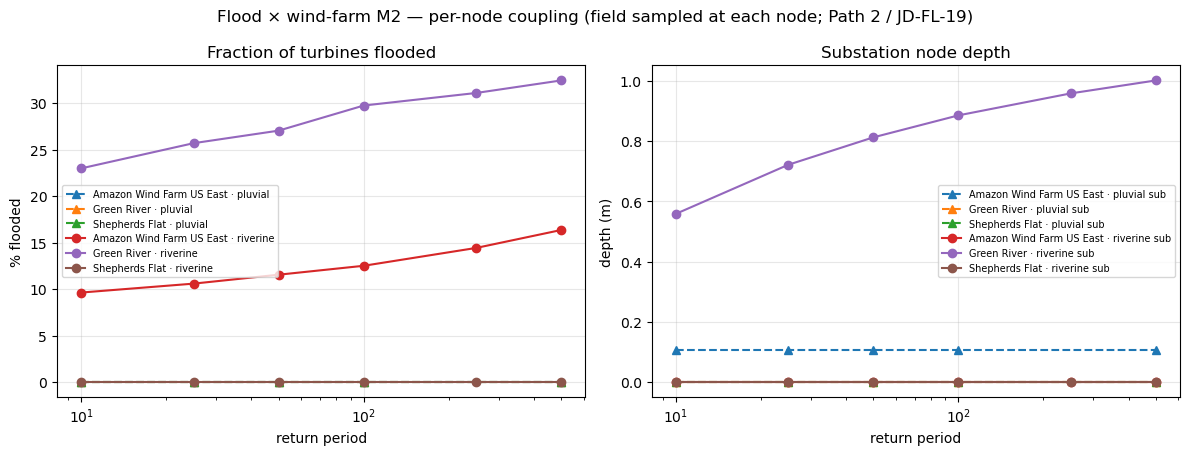

✓ riverine Green River: 100yr 30% → 500yr 32% turbines wet; baseline dry
✓ coastal Amazon Wind Farm US East: nodes flooded by cat {1: 0, 2: 0, 3: 65, 4: 104, 5: 105} (pad-gated, event-based)
wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/flood_wind_m2_coupling_manifest.json


In [6]:
import matplotlib.pyplot as plt
fig, (axF, axD) = plt.subplots(1, 2, figsize=(12, 4.6))
for (sp, nm), g in coup.groupby(["sub_peril", "name"]):
    g = g.sort_values("rp_years"); ls = "o-" if sp == "riverine" else "^--"
    axF.plot(g["rp_years"].to_numpy(), (g["flooded_fraction"]*100).to_numpy(), ls, label=f"{nm} · {sp}")
    axD.plot(g["rp_years"].to_numpy(), g["substation_depth_m"].to_numpy(), ls, label=f"{nm} · {sp} sub")
for ax, ttl, yl in [(axF, "Fraction of turbines flooded", "% flooded"), (axD, "Substation node depth", "depth (m)")]:
    ax.set_xscale("log"); ax.set_xlabel("return period"); ax.set_ylabel(yl); ax.set_title(ttl); ax.legend(fontsize=7); ax.grid(alpha=0.3)
fig.suptitle("Flood × wind-farm M2 — per-node coupling (field sampled at each node; Path 2 / JD-FL-19)")
fig.tight_layout()
plt.show()


HIGH, LOW = sites[0]["name"], "Shepherds Flat"
riv = coup[coup.sub_peril == "riverine"]
hi = riv[riv.name == HIGH].set_index("rp_years"); lo = riv[riv.name == LOW].set_index("rp_years")
assert hi.loc[500, "flooded_fraction"] >= hi.loc[100, "flooded_fraction"] > 0, "riverine high site should grow 100→500yr"
assert lo.loc[500, "flooded_fraction"] == 0, "riverine baseline should be dry"
print(f"✓ riverine {HIGH}: 100yr {hi.loc[100,'flooded_fraction']*100:.0f}% → 500yr {hi.loc[500,'flooded_fraction']*100:.0f}% turbines wet; baseline dry")

if len(coa):
    print(f"✓ coastal {coastal_sites[0]['name']}: nodes flooded by cat {coa_ladder[coastal_sites[0]['slug']]} (pad-gated, event-based)")

manifest = {
    "peril": "flood", "asset": "wind_farm", "layer": "M2",
    "coupling_type": "site_conditioned_per_node — Path 2 (JD-FL-19): per-node coupling moved M1→M2. UNIFIED M2 — "
                     "riverine bathtub + pluvial pad-gated ponding (RP frame) + coastal SLOSH surge (event frame) "
                     "all computed here from the shared M1 fields/catalog (JD-FL-17, wind all-three site)",
    "rp_rows": json.loads(coup.to_json(orient="records")),                       # riverine + pluvial (RP-indexed)
    "coastal_event_rows": json.loads(coa.to_json(orient="records")) if len(coa) else [],   # coastal (per-storm)
    "coastal_nodes_flooded_by_cat": coa_ladder,
    "coastal_depth_source": COASTAL_DEPTH_SOURCE,
    "rows": json.loads(coup.to_json(orient="records")),                          # back-compat alias (= rp_rows)
}
(OUT / "flood_wind_m2_coupling_manifest.json").write_text(json.dumps(manifest, indent=2))
print("wrote:", OUT / "flood_wind_m2_coupling_manifest.json")